In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os

sys.path.append("../src")
from utils import save_plot, set_style, save_report

set_style()


In [2]:
df = pd.read_csv("../data/superstore.csv", encoding="latin-1")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
df.head()


Shape: (9994, 21)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Data Types:
 Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

Missing Values:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment 

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
# Parse dates
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

# Drop duplicates (if any)
df.drop_duplicates(inplace=True)

# Extract time features
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month_Name"] = df["Order Date"].dt.strftime("%b")
df["YearMonth"] = df["Order Date"].dt.to_period("M")

print("Cleaned shape:", df.shape)
df.describe()


Cleaned shape: (9994, 25)


,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit,Year,Month
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355,2016-05-03 23:06:58.571142,55190.379428,229.858001,3.789574,0.156203,28.656896,2015.722233,7.809686
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,2014.000000,1.000000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750,2015.000000,5.000000
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500,2016.000000,9.000000
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000,2017.000000,11.000000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000,2017.000000,12.000000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108,1.123555,3.284654


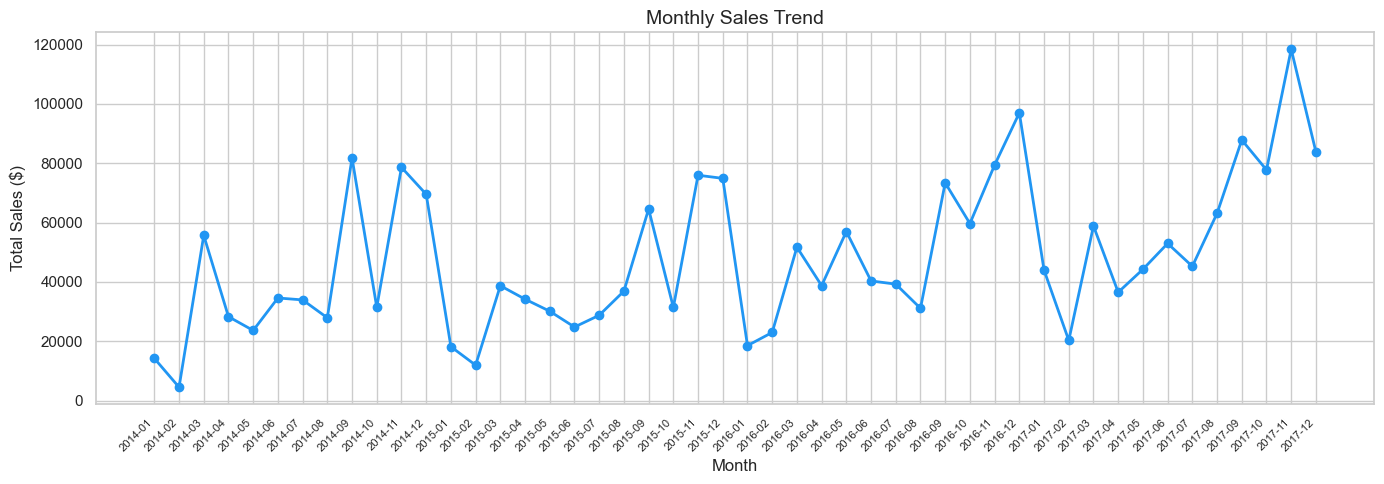

In [4]:
monthly_sales = df.groupby("YearMonth")["Sales"].sum().reset_index()
monthly_sales["YearMonth"] = monthly_sales["YearMonth"].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly_sales["YearMonth"], monthly_sales["Sales"], marker="o", linewidth=2, color="#2196F3")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.tight_layout()
save_plot("01_monthly_sales_trend.png")


C:\Users\parik\AppData\Local\Temp\ipykernel_1788\828318927.py:18: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\parik\Downloads\superstore-sales-eda\notebooks\../src\utils.py:12: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.savefig(os.path.join(OUTPUT_PLOTS, filename), bbox_inches='tight', dpi=150)
C:\Users\parik\Downloads\superstore-sales-eda\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


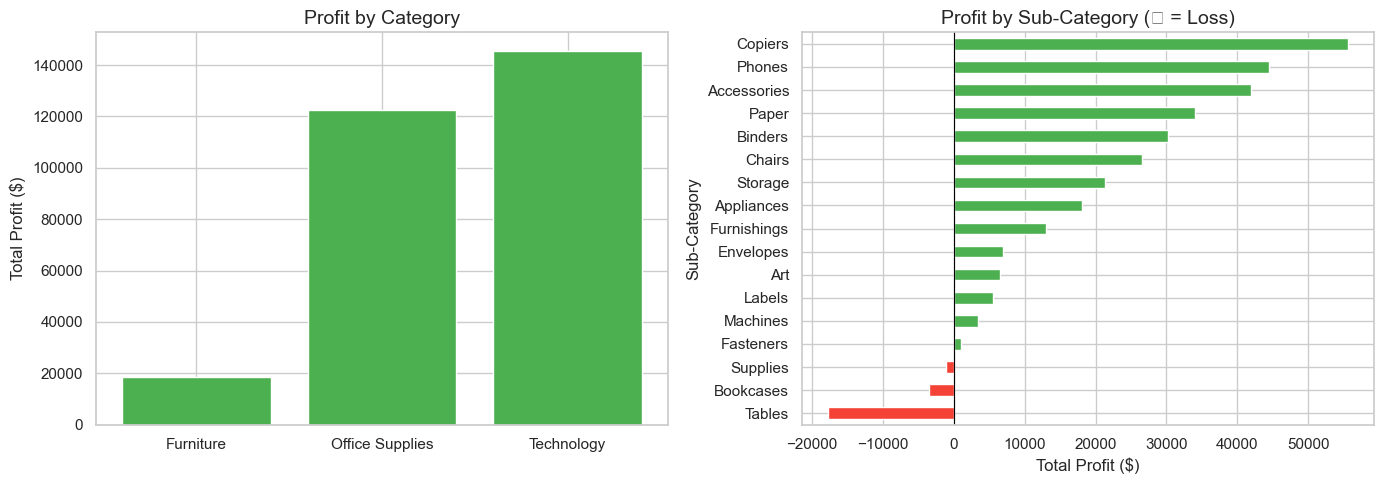

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Profit by Category
cat_profit = df.groupby("Category")["Profit"].sum().reset_index()
colors = ["#4CAF50" if x > 0 else "#F44336" for x in cat_profit["Profit"]]
axes[0].bar(cat_profit["Category"], cat_profit["Profit"], color=colors)
axes[0].set_title("Profit by Category")
axes[0].set_ylabel("Total Profit ($)")

# Profit by Sub-Category
sub_profit = df.groupby("Sub-Category")["Profit"].sum().sort_values()
colors2 = ["#F44336" if x < 0 else "#4CAF50" for x in sub_profit]
sub_profit.plot(kind="barh", color=colors2, ax=axes[1])
axes[1].set_title("Profit by Sub-Category (🔴 = Loss)")
axes[1].set_xlabel("Total Profit ($)")
axes[1].axvline(0, color="black", linewidth=0.8)

plt.tight_layout()
save_plot("02_profit_analysis.png")


C:\Users\parik\AppData\Local\Temp\ipykernel_1788\3355910016.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_sales.index, y=cat_sales.values, palette="Blues_d", ax=axes[0])
C:\Users\parik\AppData\Local\Temp\ipykernel_1788\3355910016.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sub_sales.values, y=sub_sales.index, palette="viridis", ax=axes[1])


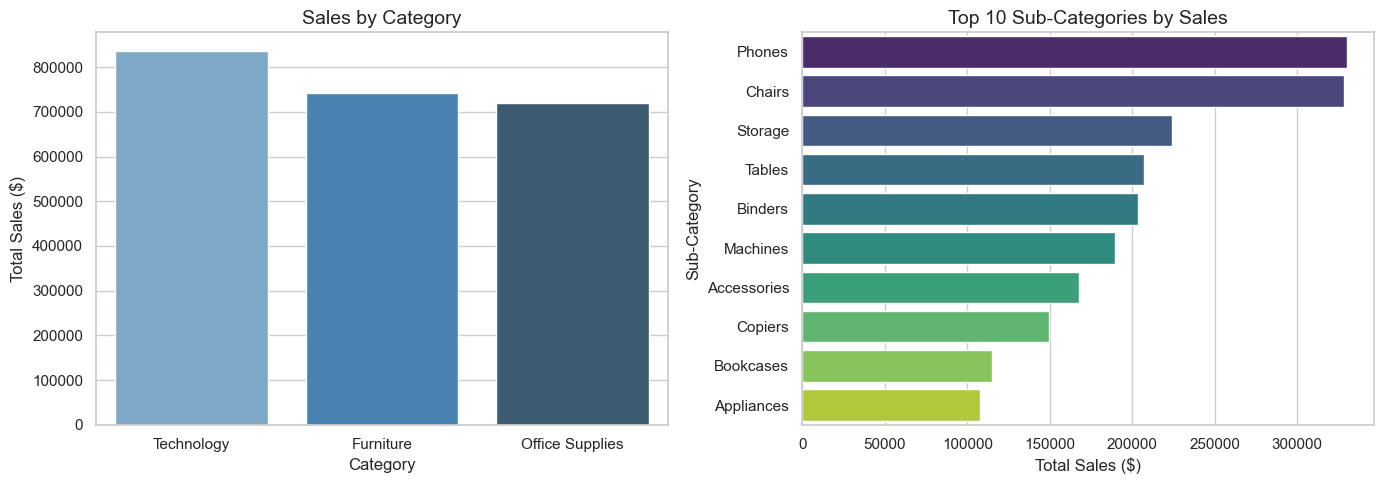

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Category sales
cat_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
sns.barplot(x=cat_sales.index, y=cat_sales.values, palette="Blues_d", ax=axes[0])
axes[0].set_title("Sales by Category")
axes[0].set_ylabel("Total Sales ($)")

# Sub-category top 10
sub_sales = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False).head(10)
sns.barplot(x=sub_sales.values, y=sub_sales.index, palette="viridis", ax=axes[1])
axes[1].set_title("Top 10 Sub-Categories by Sales")
axes[1].set_xlabel("Total Sales ($)")

plt.tight_layout()
save_plot("03_category_sales.png")


C:\Users\parik\AppData\Local\Temp\ipykernel_1788\2685936406.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_data, x="Region", y="Sales", palette="Set2", ax=axes[0])
C:\Users\parik\AppData\Local\Temp\ipykernel_1788\2685936406.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_data, x="Region", y="Profit", palette="RdYlGn", ax=axes[1])


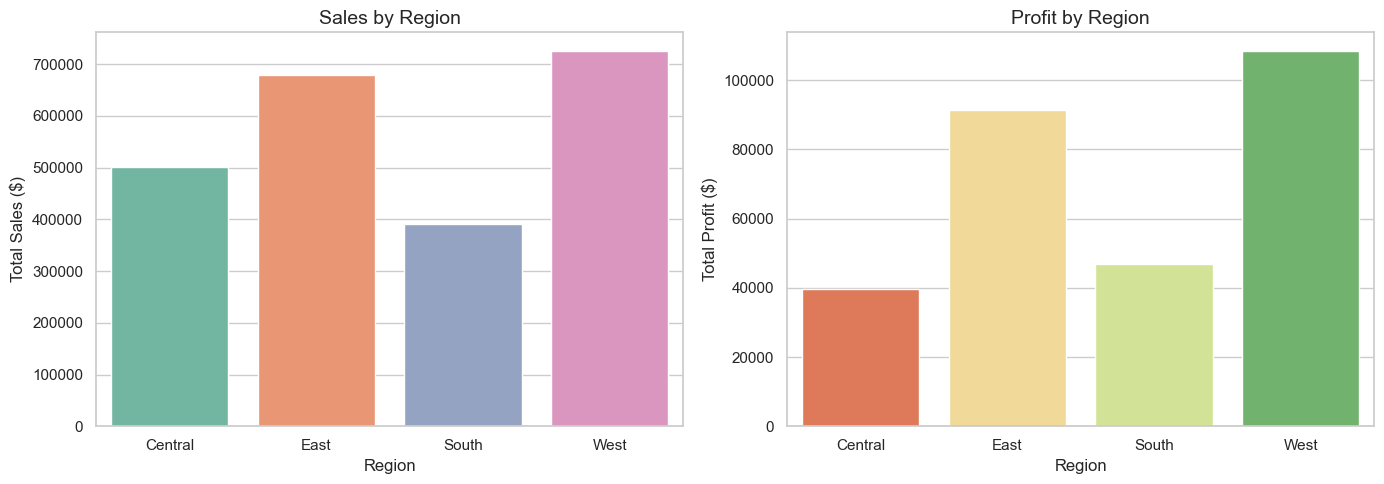

In [7]:
region_data = df.groupby("Region")[["Sales", "Profit"]].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=region_data, x="Region", y="Sales", palette="Set2", ax=axes[0])
axes[0].set_title("Sales by Region")
axes[0].set_ylabel("Total Sales ($)")

sns.barplot(data=region_data, x="Region", y="Profit", palette="RdYlGn", ax=axes[1])
axes[1].set_title("Profit by Region")
axes[1].set_ylabel("Total Profit ($)")
axes[1].axhline(0, color="black", linewidth=0.8)

plt.tight_layout()
save_plot("04_region_analysis.png")


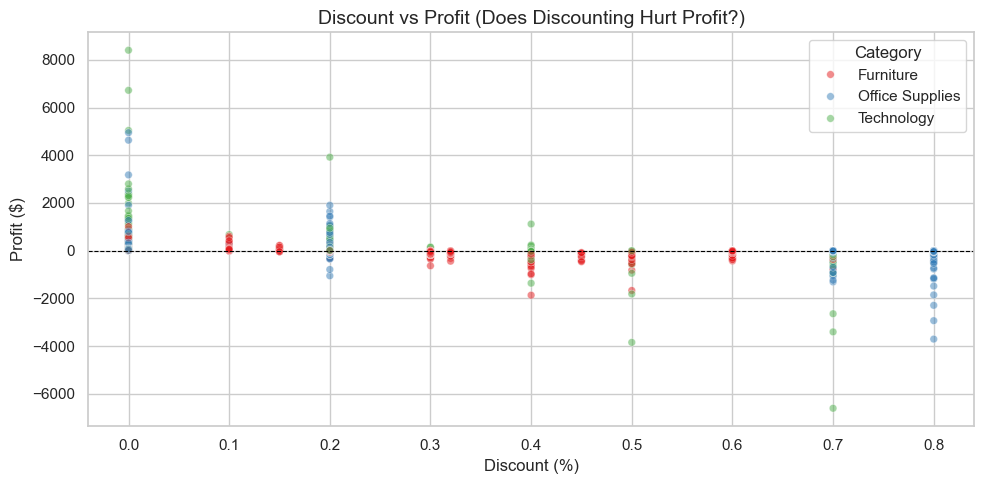

Correlation between Discount and Profit: -0.2195


In [8]:
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df, x="Discount", y="Profit",
    hue="Category", alpha=0.5, palette="Set1", s=30
)
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.title("Discount vs Profit (Does Discounting Hurt Profit?)")
plt.xlabel("Discount (%)")
plt.ylabel("Profit ($)")
plt.tight_layout()
save_plot("05_discount_vs_profit.png")

# Correlation
corr = df["Discount"].corr(df["Profit"])
print(f"Correlation between Discount and Profit: {corr:.4f}")


C:\Users\parik\AppData\Local\Temp\ipykernel_1788\4240590942.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_customers.values, y=top_customers.index, palette="magma", ax=axes[1])


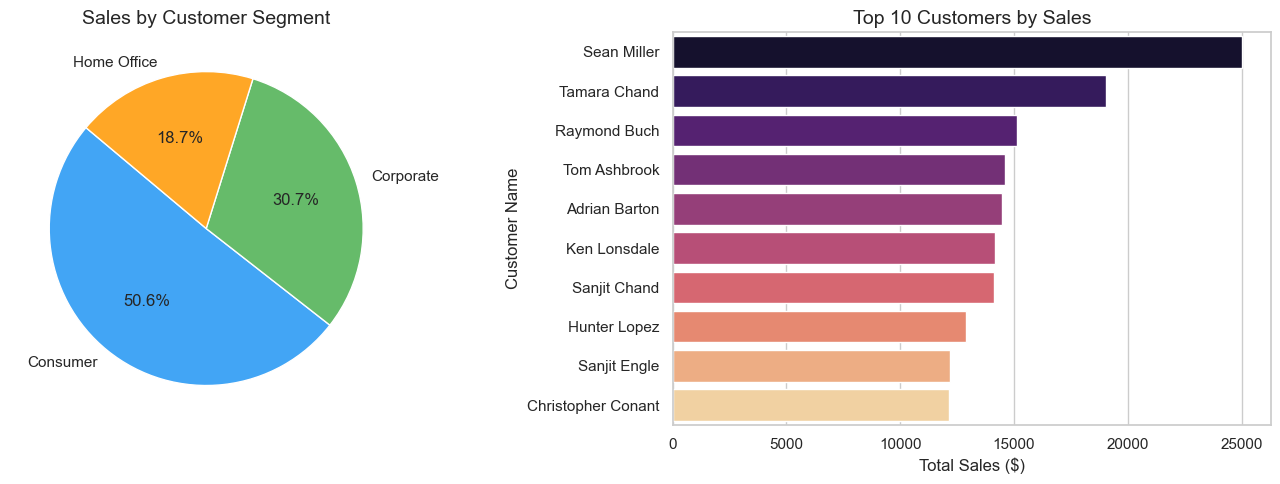

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Segment sales pie
seg_sales = df.groupby("Segment")["Sales"].sum()
axes[0].pie(seg_sales, labels=seg_sales.index, autopct="%1.1f%%",
            colors=["#42A5F5", "#66BB6A", "#FFA726"], startangle=140)
axes[0].set_title("Sales by Customer Segment")

# Top 10 customers
top_customers = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_customers.values, y=top_customers.index, palette="magma", ax=axes[1])
axes[1].set_title("Top 10 Customers by Sales")
axes[1].set_xlabel("Total Sales ($)")

plt.tight_layout()
save_plot("06_segment_customers.png")


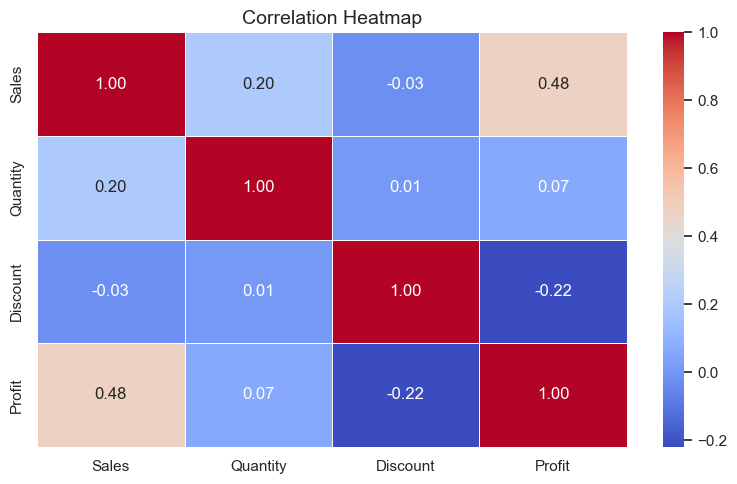

In [10]:
plt.figure(figsize=(8, 5))
numeric_cols = df[["Sales", "Quantity", "Discount", "Profit"]]
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
save_plot("07_correlation_heatmap.png")


In [11]:
top_cat = df.groupby("Category")["Sales"].sum().idxmax()
worst_sub = df.groupby("Sub-Category")["Profit"].sum().idxmin()
best_region = df.groupby("Region")["Profit"].sum().idxmax()
discount_corr = df["Discount"].corr(df["Profit"])

report = f"""# Superstore Sales EDA — Summary Report

## Key Findings

- **Top Category by Sales:** {top_cat}
- **Worst Sub-Category (Loss):** {worst_sub}
- **Most Profitable Region:** {best_region}
- **Discount–Profit Correlation:** {discount_corr:.4f} (negative = discounts hurt profit)

## Recommendations

1. Reduce or eliminate discounts on low-margin sub-categories like {worst_sub}
2. Focus marketing efforts on the {best_region} region for higher ROI
3. Technology products drive the most revenue — prioritize inventory
4. Consumer segment leads sales; target B2B (Corporate) to grow profit mix
"""

save_report(report, "summary.md")
print(report)


Report saved: outputs/reports/summary.md
# Superstore Sales EDA — Summary Report

## Key Findings

- **Top Category by Sales:** Technology
- **Worst Sub-Category (Loss):** Tables
- **Most Profitable Region:** West
- **Discount–Profit Correlation:** -0.2195 (negative = discounts hurt profit)

## Recommendations

1. Reduce or eliminate discounts on low-margin sub-categories like Tables
2. Focus marketing efforts on the West region for higher ROI
3. Technology products drive the most revenue — prioritize inventory
4. Consumer segment leads sales; target B2B (Corporate) to grow profit mix

